In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
df = pd.read_csv('melb_data.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (13580, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  

In [ ]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
 Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64

Duplicated rows: 0


In [ ]:
df['BuildingArea'] = df['BuildingArea'].fillna(df['BuildingArea'].median())
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
df['Car'] = df['Car'].fillna(df['Car'].median())
df['CouncilArea'] = df['CouncilArea'].fillna('Unknown')

print(df.isnull().sum().sum())

0


In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows")

Removed 0 duplicate rows


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
print(df['Date'].dtype)
print(df['Date'].min(), "->", df['Date'].max())

datetime64[ns]
2016-01-28 00:00:00 -> 2017-09-23 00:00:00


In [ ]:
print(df['Type'].value_counts())
print(df['Method'].value_counts())
print(df['Regionname'].value_counts())

Type
h    9449
u    3017
t    1114
Name: count, dtype: int64
Method
S     9022
SP    1703
PI    1564
VB    1199
SA      92
Name: count, dtype: int64
Regionname
Southern Metropolitan         4695
Northern Metropolitan         3890
Western Metropolitan          2948
Eastern Metropolitan          1471
South-Eastern Metropolitan     450
Eastern Victoria                53
Northern Victoria               41
Western Victoria                32
Name: count, dtype: int64


In [ ]:
df['Sale_Year'] = df['Date'].dt.year
df['Sale_Month'] = df['Date'].dt.month
df['Property_Age'] = (df['Sale_Year'] - df['YearBuilt']).clip(lower=0)
df['Total_Rooms'] = df['Bedroom2'] + df['Bathroom']

df[['Sale_Year', 'Sale_Month', 'Property_Age', 'Total_Rooms']].head()

,Sale_Year,Sale_Month,Property_Age,Total_Rooms
0,2016,12,46.0,3.0
1,2016,2,116.0,3.0
2,2017,3,117.0,5.0
3,2017,3,47.0,5.0
4,2016,6,2.0,4.0


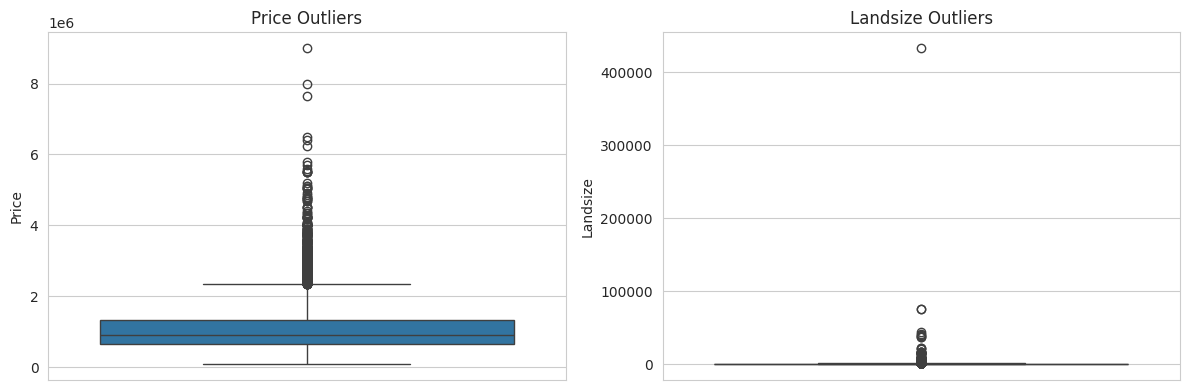

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=df['Price'], ax=axes[0])
axes[0].set_title('Price Outliers')
sns.boxplot(y=df['Landsize'], ax=axes[1])
axes[1].set_title('Landsize Outliers')
plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers_iqr(data, column, k=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

before = df.shape[0]
for col in ['Price', 'Landsize']:
    df = remove_outliers_iqr(df, col)
print(f"Removed {before - df.shape[0]} outlier rows")
print("New shape:", df.shape)

Removed 953 outlier rows
New shape: (12627, 25)


In [ ]:
df = df.drop(columns=['Address', 'SellerG', 'Date', 'Postcode'])
df.head()

,Suburb,Rooms,Type,Price,Method,Distance,Bedroom2,Bathroom,Car,Landsize,...,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Sale_Year,Sale_Month,Property_Age,Total_Rooms
0,Abbotsford,2,h,1480000.0,S,2.5,2.0,1.0,1.0,202.0,...,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016,12,46.0,3.0
1,Abbotsford,2,h,1035000.0,S,2.5,2.0,1.0,0.0,156.0,...,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016,2,116.0,3.0
2,Abbotsford,3,h,1465000.0,SP,2.5,3.0,2.0,0.0,134.0,...,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017,3,117.0,5.0
3,Abbotsford,3,h,850000.0,PI,2.5,3.0,2.0,1.0,94.0,...,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017,3,47.0,5.0
4,Abbotsford,4,h,1600000.0,VB,2.5,3.0,1.0,2.0,120.0,...,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016,6,2.0,4.0


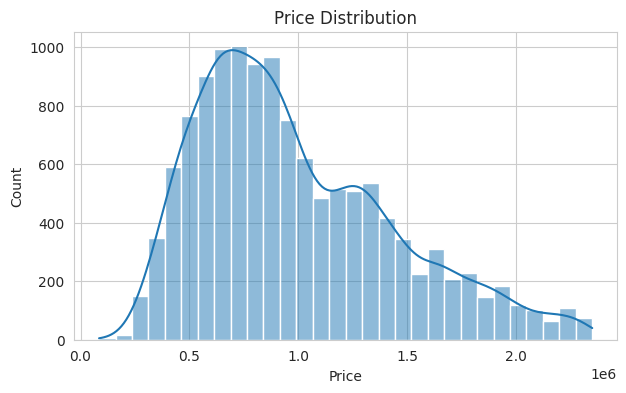

count    1.262700e+04
mean     9.888191e+05
std      4.546731e+05
min      8.500000e+04
25%      6.450000e+05
50%      8.900000e+05
75%      1.275500e+06
max      2.350000e+06
Name: Price, dtype: float64


In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()
print(df['Price'].describe())

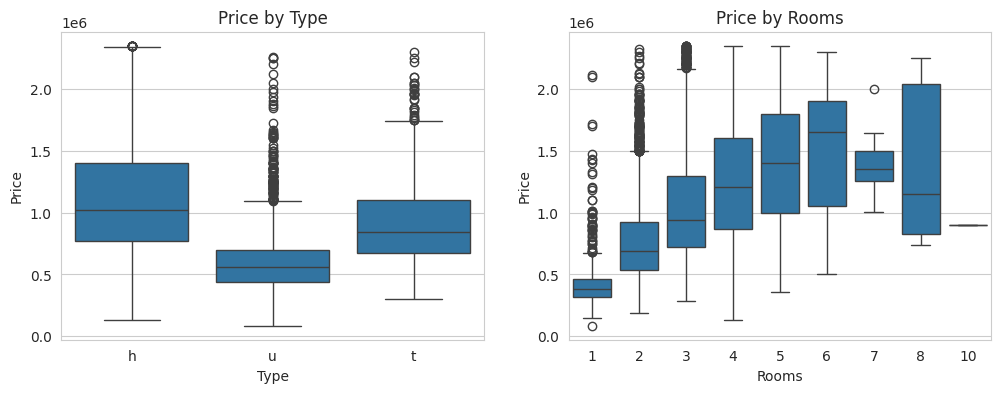

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='Type', y='Price', data=df, ax=axes[0])
axes[0].set_title('Price by Type')
sns.boxplot(x='Rooms', y='Price', data=df, ax=axes[1])
axes[1].set_title('Price by Rooms')
plt.show()

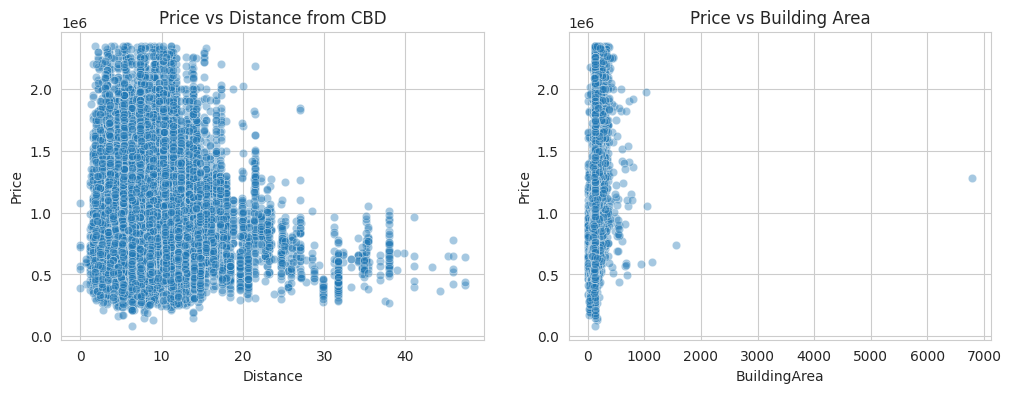

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x='Distance', y='Price', data=df, alpha=0.4, ax=axes[0])
axes[0].set_title('Price vs Distance from CBD')
sns.scatterplot(x='BuildingArea', y='Price', data=df, alpha=0.4, ax=axes[1])
axes[1].set_title('Price vs Building Area')
plt.show()

/tmp/ipykernel_923/2465699377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_price.values, y=region_price.index, palette='viridis')


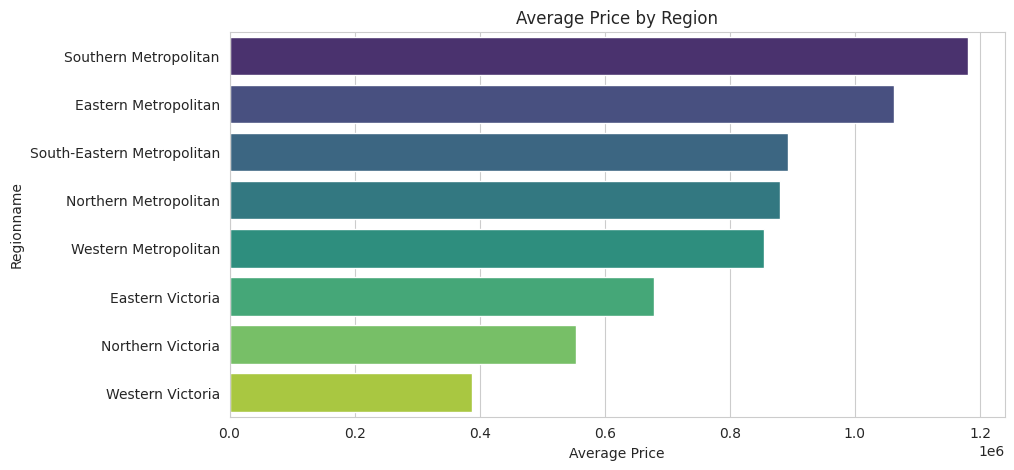

In [ ]:
plt.figure(figsize=(10,5))
region_price = df.groupby('Regionname')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=region_price.values, y=region_price.index, palette='viridis')
plt.title('Average Price by Region')
plt.xlabel('Average Price')
plt.show()

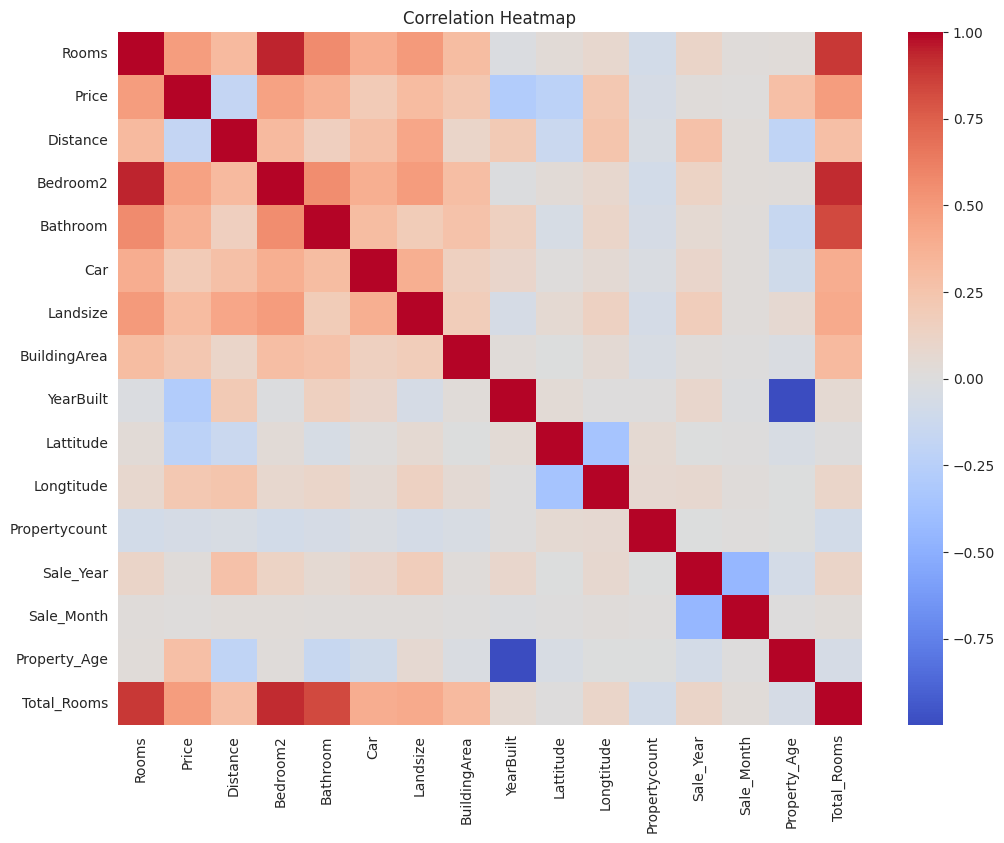

In [ ]:
plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# نعمل target تصنيفي: هل سعر البيت أعلى أو أقل من المتوسط (Median)
df['Price_Category'] = (df['Price'] >= df['Price'].median()).astype(int)
print(df['Price_Category'].value_counts())

df_model = df.copy()
cat_cols = ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']
le = LabelEncoder()
for c in cat_cols:
    df_model[c] = le.fit_transform(df_model[c].astype(str))

X = df_model.drop(columns=['Price', 'Price_Category'])
y = df_model['Price_Category']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Price_Category
1    6319
0    6308
Name: count, dtype: int64
Train shape: (10101, 20) Test shape: (2526, 20)


Accuracy: 0.8709422011084719
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1262
           1       0.87      0.87      0.87      1264

    accuracy                           0.87      2526
   macro avg       0.87      0.87      0.87      2526
weighted avg       0.87      0.87      0.87      2526



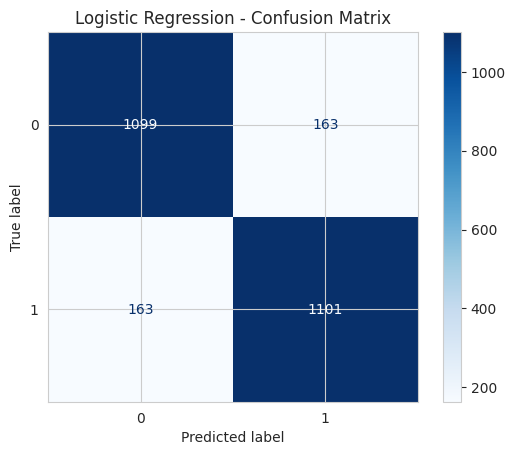

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log)).plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

Accuracy: 0.8531274742676168
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      1262
           1       0.81      0.92      0.86      1264

    accuracy                           0.85      2526
   macro avg       0.86      0.85      0.85      2526
weighted avg       0.86      0.85      0.85      2526



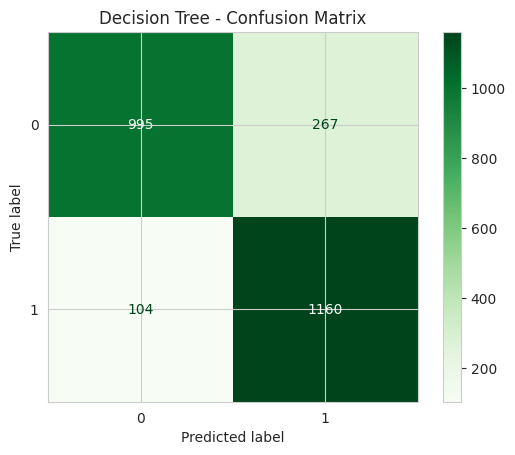

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot(cmap='Greens')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

Accuracy: 0.8990498812351544
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1262
           1       0.90      0.90      0.90      1264

    accuracy                           0.90      2526
   macro avg       0.90      0.90      0.90      2526
weighted avg       0.90      0.90      0.90      2526



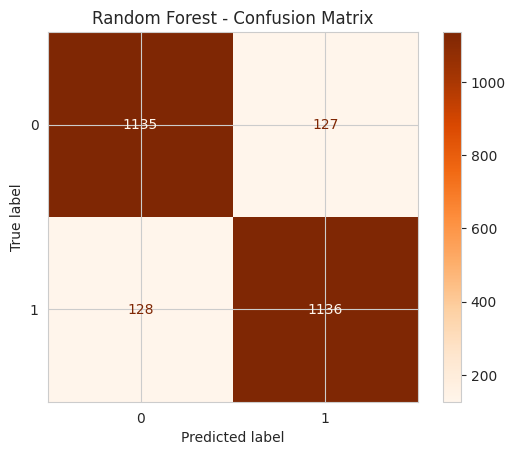

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(cmap='Oranges')
plt.title('Random Forest - Confusion Matrix')
plt.show()

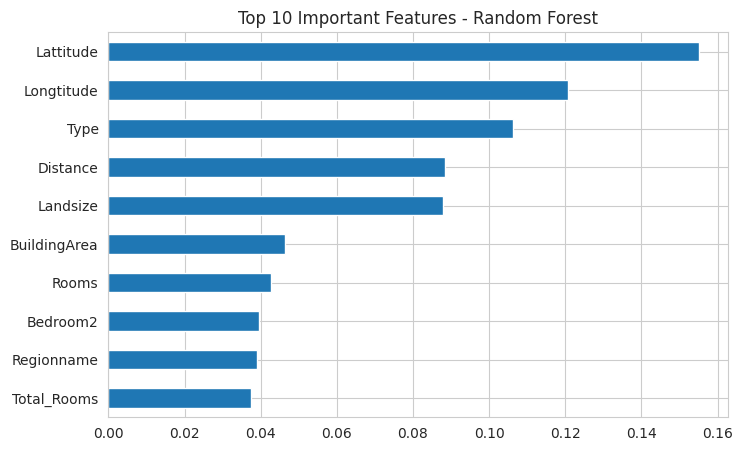

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.show()

Accuracy: 0.8867775138558986
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1262
           1       0.88      0.89      0.89      1264

    accuracy                           0.89      2526
   macro avg       0.89      0.89      0.89      2526
weighted avg       0.89      0.89      0.89      2526



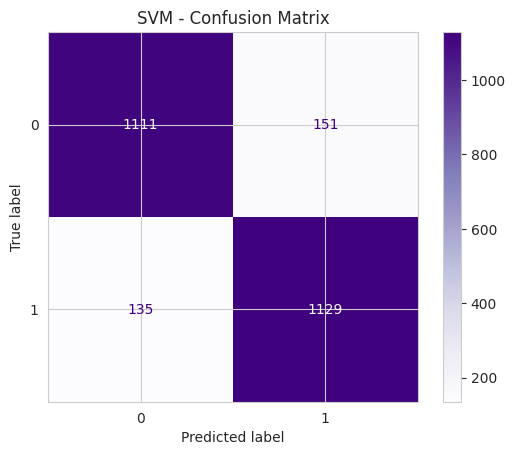

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot(cmap='Purples')
plt.title('SVM - Confusion Matrix')
plt.show()

Accuracy: 0.8638163103721298
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1262
           1       0.84      0.89      0.87      1264

    accuracy                           0.86      2526
   macro avg       0.87      0.86      0.86      2526
weighted avg       0.87      0.86      0.86      2526



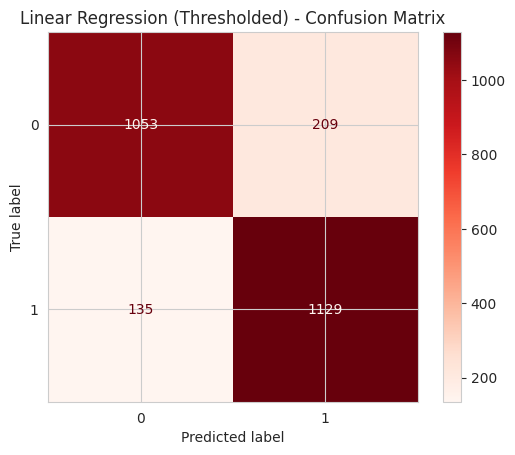

In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Linear Regression بيطلع رقم مستمر، فنحوله لتصنيف بعتبة 0.5
y_pred_lin_continuous = lin_model.predict(X_test)
y_pred_lin = (y_pred_lin_continuous >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_lin))
print(classification_report(y_test, y_pred_lin))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lin)).plot(cmap='Reds')
plt.title('Linear Regression (Thresholded) - Confusion Matrix')
plt.show()

                 Model  Accuracy
2        Random Forest  0.899050
3                  SVM  0.886778
0  Logistic Regression  0.870942
4    Linear Regression  0.863816
1        Decision Tree  0.853127


/tmp/ipykernel_923/2765904608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')


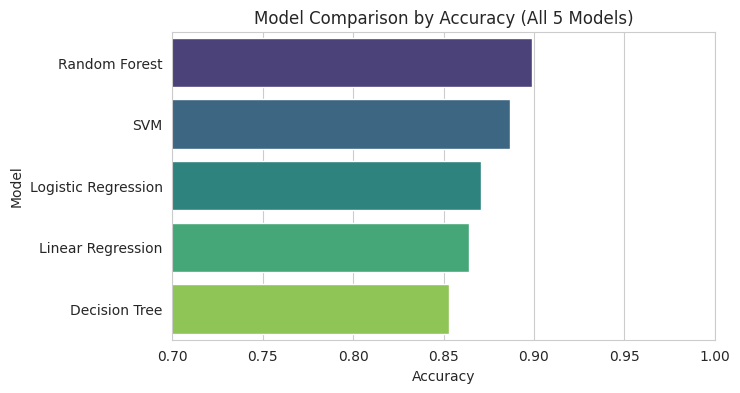

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Linear Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lin)
    ]
})
results = results.sort_values('Accuracy', ascending=False)
print(results)

plt.figure(figsize=(7,4))
sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')
plt.title('Model Comparison by Accuracy (All 5 Models)')
plt.xlim(0.7, 1.0)
plt.show()

In [ ]:
df.to_csv('melb_data_cleaned.csv', index=False)
from google.colab import files
files.download('melb_data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>